# DMI benchmark problem in 1D
Implementation of the 1D problem proposed in David Cortés-Ortuño et al 2018 New J. Phys. 20 113015.

## Simulation
### Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants

import neuralmag as nm

2025-05-12 21:32:32 NeuralMag:INFO [NeuralMag] Version 0.9.1


### Create mesh and state
Next we set up a state with a 1D mesh object (a mesh with nodes only in the x-direction).

In [2]:
mesh = nm.Mesh((100,), (1e-9, 1e-9, 1e-9))
state = nm.State(mesh)

2025-05-12 21:32:32 NeuralMag:INFO [Mesh] 1D, 100 (size = 1e-09 x 1e-09 x 1e-09)
2025-05-12 21:32:33 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2025-05-12 21:32:33 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-05-12 21:32:33 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2025-05-12 21:32:33 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float32, backend = jax)


### Material parameters and initial magnetization
The material parameters are set up according to the proposed problem and set an initial magnetization in the z-direction.


In [3]:
state.material.Ms = 0.86e6
state.material.A = 1.3e-11
state.material.Ku = 0.4e6
state.material.Ku_axis = [0, 0, 1]
state.material.Di = 3e-3
state.material.Di_axis = [0, 0, 1]
state.material.alpha = 1.0

state.m = nm.VectorFunction(state).fill((0, 0, 1))

### Effective field

Next, we set up the effective field which is comprised of contributions from interface DMI, exchange and uniaxial anisotropy. For this example, we do no explicitly account for the demgnetization field, but rather use an effective anisotropy that also accounts for the shape anisotropy.

After initializing the effective field, we relax the system into an energetic equilibrium.

In [4]:
# initialize effective field
nm.InterfaceDMIField().register(state, "dmi")
nm.ExchangeField().register(state, "exchange")
nm.UniaxialAnisotropyField().register(state, "aniso")
nm.TotalField("aniso", "dmi", "exchange").register(state)

# relax to energetic minimum
llg = nm.LLGSolver(state)
llg.relax(1e9)

2025-05-12 21:32:34 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_dmi', energy: 'E_dmi')
2025-05-12 21:32:34 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-05-12 21:32:34 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso')
2025-05-12 21:32:34 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')
2025-05-12 21:32:34 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2025-05-12 21:32:34 NeuralMag:INFO [LLGSolverJAX] Relaxation started, initial energy E = -4e-20 J
2025-05-12 21:32:35 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 8.68685e+11) 1/s
2025-05-12 21:32:37 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 2.0257e+10) 1/s
2025-05-12 21:32:37 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 6.25765e+09) 1/s
2025-05-12 21:32:37 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 2.23556e+09) 

## Visualization
We extract the magnetization data from the discretized magnetization field stored in ```state.m.tensor``` and compare it with the analytical solution presented in the original work by Cortés-Ortuño et al.

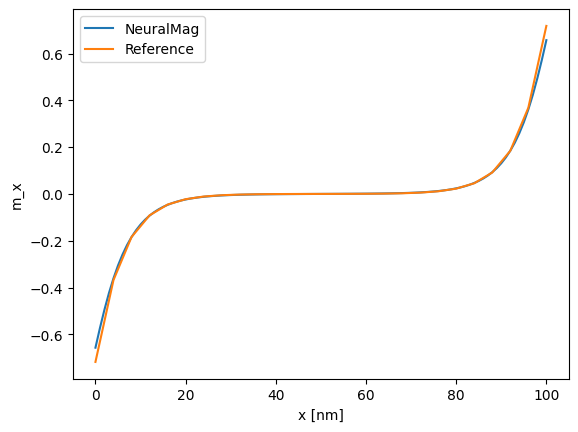

In [5]:
data = np.zeros((state.m.tensor.shape[0], 4))
data[:, 0] = np.arange(data.shape[0])
data[:, (1, 2, 3)] = state.m.tensor[:, :]

ref = np.array(
    [
        -7.17885457e-01,
        -3.68028209e-01,
        -1.84133801e-01,
        -9.15314286e-02,
        -4.54233302e-02,
        -2.25310767e-02,
        -1.11735402e-02,
        -5.53930074e-03,
        -2.74312482e-03,
        -1.35264383e-03,
        -6.55428327e-04,
        -2.94184151e-04,
        -8.37557859e-05,
        8.37314816e-05,
        2.94160582e-04,
        6.55405003e-04,
        1.35262473e-03,
        2.74309370e-03,
        5.53925965e-03,
        1.11734897e-02,
        2.25310031e-02,
        4.54232225e-02,
        9.15313263e-02,
        1.84133572e-01,
        3.68027672e-01,
        7.17884296e-01,
    ]
)


plt.plot(data[:, 0], data[:, 1], label="NeuralMag")
plt.plot(data[::4, 0], ref, label="Reference")
plt.legend()
plt.xlabel("x [nm]")
plt.ylabel("m_x")
plt.show()